- definiujemy klase $CroppedToothbrushDataset$ z przycietymi obrazami szczoteczek po preprocessingu
- dzielimy na zbiory treningowe/testowe

In [1]:
import os
import torch
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader, Subset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

current_dir = os.getcwd()
if current_dir.endswith('notebooks'):
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
else:
    PROJECT_ROOT = current_dir

CROPPED_DATA_DIR = os.path.join(PROJECT_ROOT, 'data_cropped')

class CroppedToothbrushDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.samples = []
        
        defective_dir = os.path.join(data_dir, 'train', 'defective')
        if os.path.exists(defective_dir):
            for img_name in os.listdir(defective_dir):
                if img_name.endswith('.png'):
                    img_path = os.path.join(defective_dir, img_name)
                    mask_name = img_name.replace('.png', '_mask.png')
                    mask_path = os.path.join(data_dir, 'ground_truth', 'defective', mask_name)
                    self.samples.append((img_path, mask_path))
                    
        good_dir = os.path.join(data_dir, 'train', 'good')
        if os.path.exists(good_dir):
            for img_name in os.listdir(good_dir):
                if img_name.endswith('.png'):
                    img_path = os.path.join(good_dir, img_name)
                    self.samples.append((img_path, None))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if mask_path and os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype(np.float32)
        else:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)
            
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        return image, mask

def get_transforms(is_train=True, img_size=(256, 256)):
    if is_train:
        return A.Compose([
            A.Resize(height=img_size[0], width=img_size[1]),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(height=img_size[0], width=img_size[1]),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

BATCH_SIZE = 8
VALIDATION_SIZE = 15
RANDOM_SEED = 42

train_transforms = get_transforms(is_train=True)
valid_transforms = get_transforms(is_train=False)

base_train_dataset = CroppedToothbrushDataset(CROPPED_DATA_DIR, transform=train_transforms)
base_valid_dataset = CroppedToothbrushDataset(CROPPED_DATA_DIR, transform=valid_transforms)

indices = list(range(len(base_train_dataset)))
np.random.seed(RANDOM_SEED)
np.random.shuffle(indices)

train_size = len(base_train_dataset) - VALIDATION_SIZE
train_indices = indices[:train_size]
valid_indices = indices[train_size:]

train_dataset = Subset(base_train_dataset, train_indices)
valid_dataset = Subset(base_valid_dataset, valid_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Cropped dataset loaded! Training samples: {len(train_dataset)}, Validation: {len(valid_dataset)}")

c:\Users\bielo\miniforge33\envs\ImageProcessing\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cropped dataset loaded! Training samples: 75, Validation: 15


- tworzymy model sieci - transfer learning
- sieć: U-Net + ResNet34
- U-Net to architekruta segmentacji:
    - encoder uczy się abstrakcyjnie obrazu - encoderem w naszej sieci U-Net jest ResNet34
    - decoder odtwarza szczegóły i buduje maskę

- funckja straty - "DiceLoss" - czytalem ze jest dobry gdy obiekt (wada) zajmuje mały procent obrazu i ejst dużo tła i mało defektu
- optimizer: Adam
- learning rate - 0.001
- trening przez 40 epok
- batch size=8 (ile obrazów naraz)


In [2]:
import segmentation_models_pytorch as smp
import time
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computation device configured to: {device}")

model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1                       
).to(device)

criterion = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def calculate_iou(pred_mask, true_mask, threshold=0.5):
    probs = torch.sigmoid(pred_mask)
    preds = (probs > threshold).float()
    intersection = (preds * true_mask).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + true_mask.sum(dim=(2, 3)) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

EPOCHS = 40
best_valid_iou = 0.0

os.makedirs('../submission', exist_ok=True)
print("Starting the professional training loop on CROPPED data...")

for epoch in range(EPOCHS):
    start_time = time.time()
    
    model.train()
    train_loss, train_iou = 0.0, 0.0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        if masks.dim() == 3:
            masks = masks.unsqueeze(1)
            
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_iou += calculate_iou(outputs, masks) * images.size(0)
        
    train_loss = train_loss / len(train_loader.dataset)
    train_iou = train_iou / len(train_loader.dataset)
    
    model.eval()
    valid_loss, valid_iou = 0.0, 0.0
    
    with torch.no_grad():
        for images, masks in valid_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            if masks.dim() == 3:
                masks = masks.unsqueeze(1)
                
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            valid_loss += loss.item() * images.size(0)
            valid_iou += calculate_iou(outputs, masks) * images.size(0)
            
    valid_loss = valid_loss / len(valid_loader.dataset)
    valid_iou = valid_iou / len(valid_loader.dataset)
    
    if valid_iou > best_valid_iou:
        best_valid_iou = valid_iou
        torch.save(model.state_dict(), '../submission/weights.pth')
        saved_msg = " -> BEST IoU MODEL SAVED!"
    else:
        saved_msg = ""
        
    end_time = time.time()
    epoch_mins = int((end_time - start_time) / 60)
    epoch_secs = int((end_time - start_time) % 60)
    
    print(f"Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
    print(f"\tTrain Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
    print(f"\tVal. Loss: {valid_loss:.4f} | Val. IoU: {valid_iou:.4f}{saved_msg}")

print("Training on cropped dataset completed successfully!")

Computation device configured to: cpu
Starting the professional training loop on CROPPED data...
Epoch: 01 | Time: 0m 14s
	Train Loss: 0.8505 | Train IoU: 0.0223
	Val. Loss: 0.9521 | Val. IoU: 0.0239 -> BEST IoU MODEL SAVED!
Epoch: 02 | Time: 0m 13s
	Train Loss: 0.9378 | Train IoU: 0.0319
	Val. Loss: 0.9567 | Val. IoU: 0.0222
Epoch: 03 | Time: 0m 13s
	Train Loss: 0.9052 | Train IoU: 0.3728
	Val. Loss: 0.9443 | Val. IoU: 0.0247 -> BEST IoU MODEL SAVED!
Epoch: 04 | Time: 0m 16s
	Train Loss: 0.7808 | Train IoU: 0.4952
	Val. Loss: 0.9555 | Val. IoU: 0.0227
Epoch: 05 | Time: 0m 17s
	Train Loss: 0.8744 | Train IoU: 0.4682
	Val. Loss: 0.9307 | Val. IoU: 0.0345 -> BEST IoU MODEL SAVED!
Epoch: 06 | Time: 0m 16s
	Train Loss: 0.8171 | Train IoU: 0.5326
	Val. Loss: 0.9566 | Val. IoU: 0.0222
Epoch: 07 | Time: 0m 16s
	Train Loss: 0.8310 | Train IoU: 0.2307
	Val. Loss: 0.8758 | Val. IoU: 0.0506 -> BEST IoU MODEL SAVED!
Epoch: 08 | Time: 0m 16s
	Train Loss: 0.6849 | Train IoU: 0.6139
	Val. Loss: 0.946

- ładuje nalepsze wagi
- szybka wizualizacja kontrolna

Ładowanie najlepszych wag modelu z dysku...


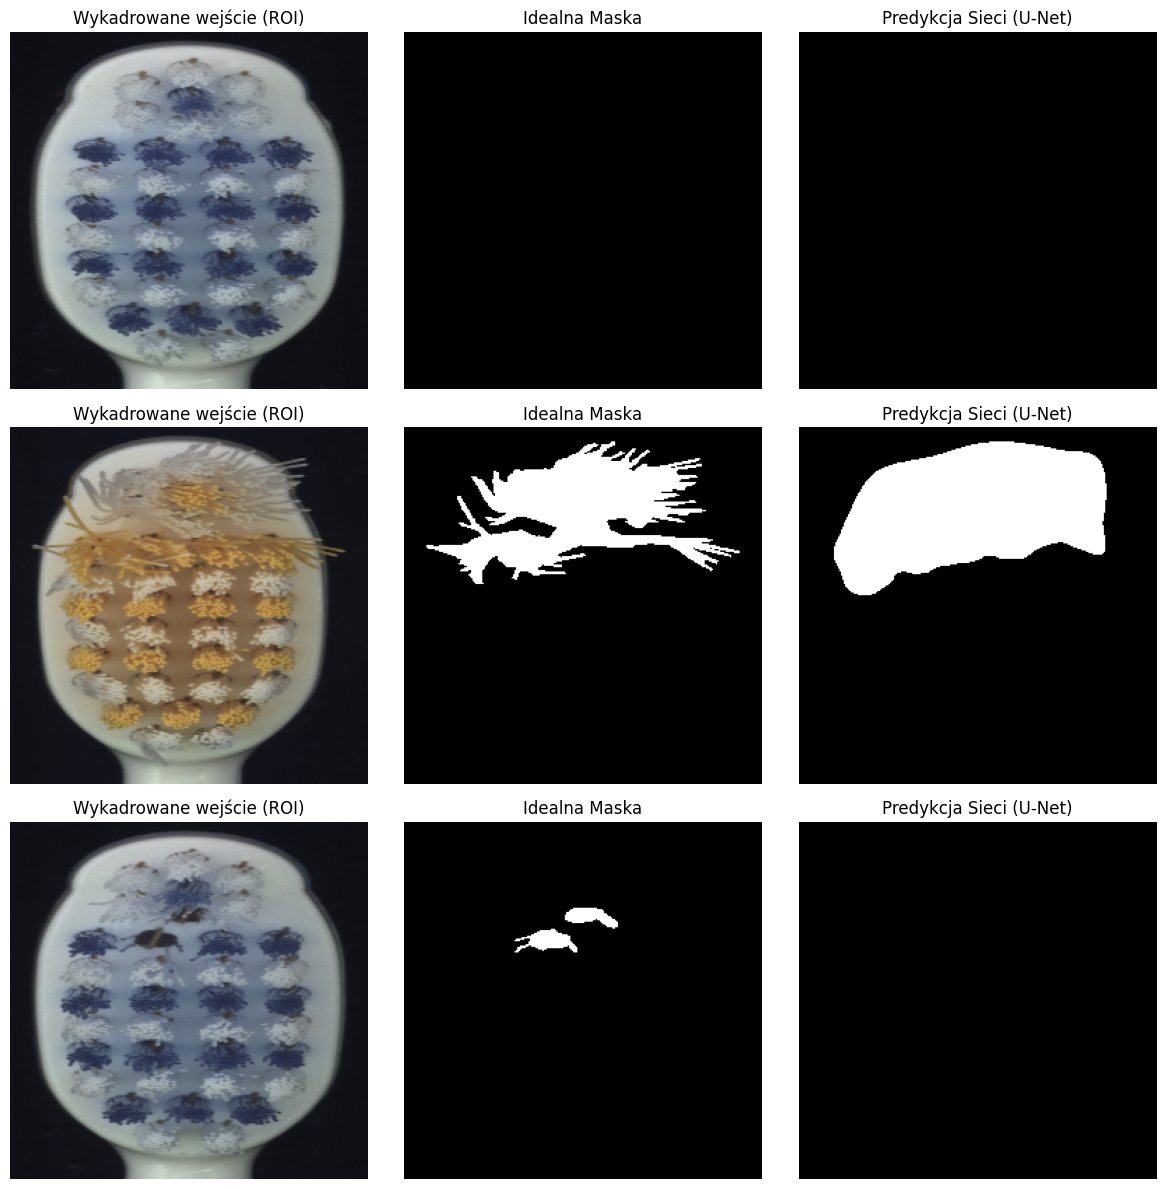

In [3]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_cropped_predictions(model, dataloader, device, num_samples=3):
    print("Ładowanie najlepszych wag modelu z dysku...")
    model.load_state_dict(torch.load('../submission/weights.pth', weights_only=True))
    model.eval()
    
    images, true_masks = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        
    images_np = images.cpu().numpy()
    true_masks_np = true_masks.cpu().numpy()
    preds_np = preds.cpu().numpy()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    
    for i in range(min(num_samples, len(images))):
        img = np.transpose(images_np[i], (1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Wykadrowane wejście (ROI)")
        axes[i, 0].axis('off')
        
        true_mask = np.squeeze(true_masks_np[i])
        axes[i, 1].imshow(true_mask, cmap='gray')
        axes[i, 1].set_title("Idealna Maska")
        axes[i, 1].axis('off')
        
        pred_mask = np.squeeze(preds_np[i])
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title("Predykcja Sieci (U-Net)")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_cropped_predictions(model, valid_loader, device, num_samples=3)

## U-Net training v2

Ulepszona wersja treningu

- AdamW + weight decay
- Dice + BCE loss
- ReduceLROnPlateau
- Early stopping

In [ ]:
import copy
import time
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

IMG_SIZE = (320, 320)
BATCH_SIZE_V2 = 8
VALID_RATIO = 0.20
RANDOM_SEED_V2 = 42

ENCODER_NAME = "resnet34"
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS_V2 = 100
EARLY_STOPPING_PATIENCE = 30

DICE_WEIGHT = 0.5
BCE_WEIGHT = 0.5

print(f"Device: {device}")
print(f"Training config: LR={LEARNING_RATE}, WD={WEIGHT_DECAY}, epochs={EPOCHS_V2}, batch={BATCH_SIZE_V2}")

# Rebuild transforms/loaders with parameterized split
train_transforms_v2 = get_transforms(is_train=True, img_size=IMG_SIZE)
valid_transforms_v2 = get_transforms(is_train=False, img_size=IMG_SIZE)

base_train_dataset_v2 = CroppedToothbrushDataset(CROPPED_DATA_DIR, transform=train_transforms_v2)
base_valid_dataset_v2 = CroppedToothbrushDataset(CROPPED_DATA_DIR, transform=valid_transforms_v2)

indices_v2 = list(range(len(base_train_dataset_v2)))
np.random.seed(RANDOM_SEED_V2)
np.random.shuffle(indices_v2)

valid_size_v2 = max(1, int(len(base_train_dataset_v2) * VALID_RATIO))
train_size_v2 = len(base_train_dataset_v2) - valid_size_v2

train_indices_v2 = indices_v2[:train_size_v2]
valid_indices_v2 = indices_v2[train_size_v2:]

train_dataset_v2 = Subset(base_train_dataset_v2, train_indices_v2)
valid_dataset_v2 = Subset(base_valid_dataset_v2, valid_indices_v2)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=BATCH_SIZE_V2, shuffle=True, num_workers=0)
valid_loader_v2 = DataLoader(valid_dataset_v2, batch_size=BATCH_SIZE_V2, shuffle=False, num_workers=0)

# Model / optimizer / scheduler / losses
model_v2 = smp.Unet(
    encoder_name=ENCODER_NAME,
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

optimizer_v2 = torch.optim.AdamW(model_v2.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler_v2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2,
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

dice_loss_fn = smp.losses.DiceLoss(mode="binary")
bce_loss_fn = nn.BCEWithLogitsLoss()

def combined_loss(logits, targets):
    return DICE_WEIGHT * dice_loss_fn(logits, targets) + BCE_WEIGHT * bce_loss_fn(logits, targets)

def calculate_iou_at_threshold(pred_mask, true_mask, threshold=0.5):
    probs = torch.sigmoid(pred_mask)
    preds = (probs > threshold).float()
    intersection = (preds * true_mask).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + true_mask.sum(dim=(2, 3)) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

print(f"V2 datasets ready -> train: {len(train_dataset_v2)}, valid: {len(valid_dataset_v2)}")

Device: cpu
Training config: LR=0.0003, WD=0.0001, epochs=100, batch=8
V2 datasets ready -> train: 72, valid: 18


In [5]:
best_valid_iou_v2 = 0.0
best_epoch_v2 = 0
best_state_dict_v2 = None
no_improve_epochs = 0

os.makedirs('../submission', exist_ok=True)

print("Starting training loop v2...")
for epoch in range(EPOCHS_V2):
    start_time = time.time()

    model_v2.train()
    train_loss_v2, train_iou_v2 = 0.0, 0.0

    for images, masks in train_loader_v2:
        images = images.to(device)
        masks = masks.to(device)

        if masks.dim() == 3:
            masks = masks.unsqueeze(1)

        optimizer_v2.zero_grad()
        outputs = model_v2(images)
        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer_v2.step()

        train_loss_v2 += loss.item() * images.size(0)
        train_iou_v2 += calculate_iou_at_threshold(outputs, masks, threshold=0.5) * images.size(0)

    train_loss_v2 = train_loss_v2 / len(train_loader_v2.dataset)
    train_iou_v2 = train_iou_v2 / len(train_loader_v2.dataset)

    model_v2.eval()
    valid_loss_v2, valid_iou_v2 = 0.0, 0.0

    with torch.no_grad():
        for images, masks in valid_loader_v2:
            images = images.to(device)
            masks = masks.to(device)

            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            outputs = model_v2(images)
            loss = combined_loss(outputs, masks)

            valid_loss_v2 += loss.item() * images.size(0)
            valid_iou_v2 += calculate_iou_at_threshold(outputs, masks, threshold=0.5) * images.size(0)

    valid_loss_v2 = valid_loss_v2 / len(valid_loader_v2.dataset)
    valid_iou_v2 = valid_iou_v2 / len(valid_loader_v2.dataset)

    scheduler_v2.step(valid_iou_v2)
    current_lr = optimizer_v2.param_groups[0]['lr']

    improved = valid_iou_v2 > best_valid_iou_v2
    if improved:
        best_valid_iou_v2 = valid_iou_v2
        best_epoch_v2 = epoch + 1
        best_state_dict_v2 = copy.deepcopy(model_v2.state_dict())
        torch.save(best_state_dict_v2, '../submission/weights_v2.pth')
        no_improve_epochs = 0
        saved_msg = " -> BEST MODEL SAVED"
    else:
        no_improve_epochs += 1
        saved_msg = ""

    end_time = time.time()
    epoch_mins = int((end_time - start_time) / 60)
    epoch_secs = int((end_time - start_time) % 60)

    print(f"Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s | LR: {current_lr:.2e}")
    print(f"\tTrain Loss: {train_loss_v2:.4f} | Train IoU@0.5: {train_iou_v2:.4f}")
    print(f"\tVal. Loss: {valid_loss_v2:.4f} | Val. IoU@0.5: {valid_iou_v2:.4f}{saved_msg}")

    if no_improve_epochs >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered after {EARLY_STOPPING_PATIENCE} epochs without improvement.")
        break

if best_state_dict_v2 is not None:
    model_v2.load_state_dict(best_state_dict_v2)

print(f"Training v2 completed. Best Val IoU@0.5: {best_valid_iou_v2:.4f} (epoch {best_epoch_v2})")

Starting training loop v2...
Epoch: 01 | Time: 0m 27s | LR: 3.00e-04
	Train Loss: 0.8267 | Train IoU@0.5: 0.0219
	Val. Loss: 0.7284 | Val. IoU@0.5: 0.0251 -> BEST MODEL SAVED
Epoch: 02 | Time: 0m 24s | LR: 3.00e-04
	Train Loss: 0.7051 | Train IoU@0.5: 0.0404
	Val. Loss: 0.6596 | Val. IoU@0.5: 0.0509 -> BEST MODEL SAVED
Epoch: 03 | Time: 0m 25s | LR: 3.00e-04
	Train Loss: 0.6506 | Train IoU@0.5: 0.0571
	Val. Loss: 0.7304 | Val. IoU@0.5: 0.0370
Epoch: 04 | Time: 0m 25s | LR: 3.00e-04
	Train Loss: 0.6119 | Train IoU@0.5: 0.1015
	Val. Loss: 0.6128 | Val. IoU@0.5: 0.0634 -> BEST MODEL SAVED
Epoch: 05 | Time: 0m 24s | LR: 3.00e-04
	Train Loss: 0.5266 | Train IoU@0.5: 0.3681
	Val. Loss: 0.5767 | Val. IoU@0.5: 0.0679 -> BEST MODEL SAVED
Epoch: 06 | Time: 0m 26s | LR: 3.00e-04
	Train Loss: 0.5665 | Train IoU@0.5: 0.3837
	Val. Loss: 0.5680 | Val. IoU@0.5: 0.0507
Epoch: 07 | Time: 0m 25s | LR: 3.00e-04
	Train Loss: 0.4989 | Train IoU@0.5: 0.4058
	Val. Loss: 0.5418 | Val. IoU@0.5: 0.0783 -> BEST M

- tesowanie różnych progów binaryzacji na walidacji
- dla każdego progu liczymy IoU 
- wybieramy najelpszy

In [6]:
threshold_candidates = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
threshold_scores = {}

model_v2.eval()
with torch.no_grad():
    for th in threshold_candidates:
        iou_sum = 0.0
        count = 0

        for images, masks in valid_loader_v2:
            images = images.to(device)
            masks = masks.to(device)

            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            outputs = model_v2(images)
            iou_sum += calculate_iou_at_threshold(outputs, masks, threshold=th) * images.size(0)
            count += images.size(0)

        threshold_scores[th] = iou_sum / max(count, 1)

best_threshold_v2 = max(threshold_scores, key=threshold_scores.get)
best_threshold_iou_v2 = threshold_scores[best_threshold_v2]

print("Threshold sweep results (IoU):")
for th, score in threshold_scores.items():
    print(f"  th={th:.2f} -> IoU={score:.4f}")

print(f"\nBest threshold: {best_threshold_v2:.2f} | IoU: {best_threshold_iou_v2:.4f}")

torch.save({
    "state_dict": model_v2.state_dict(),
    "best_threshold": best_threshold_v2,
    "best_valid_iou_at_05": best_valid_iou_v2,
    "best_valid_iou_tuned_threshold": best_threshold_iou_v2,
    "encoder": ENCODER_NAME,
    "img_size": IMG_SIZE
}, '../submission/weights_v2_with_threshold.pth')

print("Saved: ../submission/weights_v2_with_threshold.pth")

Threshold sweep results (IoU):
  th=0.30 -> IoU=0.7941
  th=0.35 -> IoU=0.7946
  th=0.40 -> IoU=0.7959
  th=0.45 -> IoU=0.7966
  th=0.50 -> IoU=0.7969
  th=0.55 -> IoU=0.7966
  th=0.60 -> IoU=0.7966
  th=0.65 -> IoU=0.7966
  th=0.70 -> IoU=0.7963

Best threshold: 0.50 | IoU: 0.7969
Saved: ../submission/weights_v2_with_threshold.pth


Ładowanie najlepszych wag modelu z dysku...


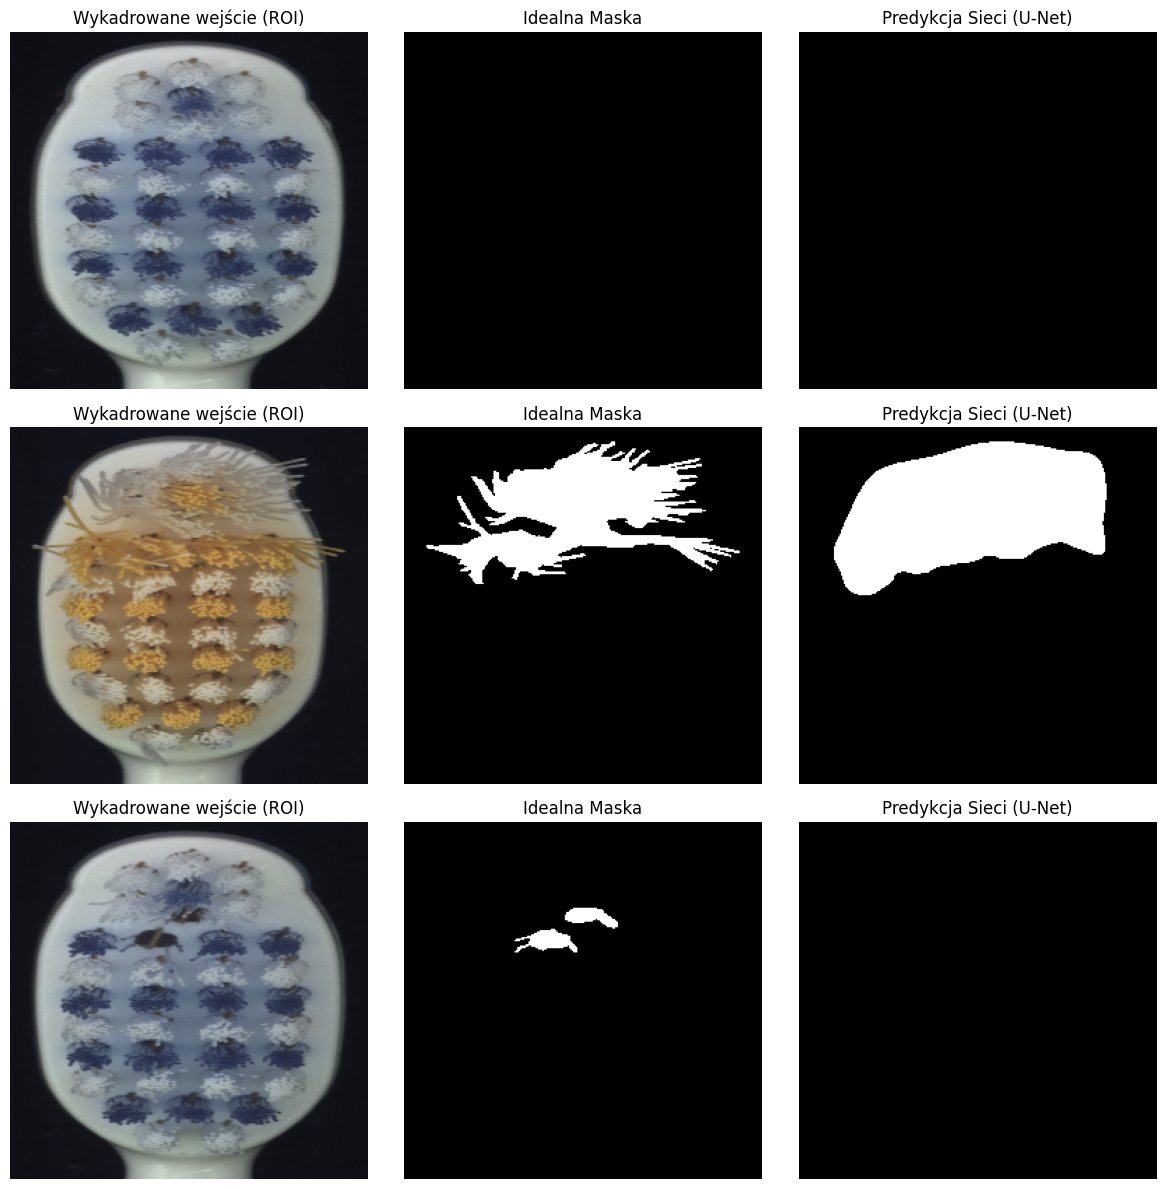

In [8]:
visualize_cropped_predictions(model_v2, valid_loader, device, num_samples=3)